# CNN (Convolutional Neural Network)




In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model

import csv
import glob
import os

from utils import *
from models import *


I0000 00:00:1780667851.860745  355476 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780667851.893907  355476 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
autoencoder = Autoencoder()

autoencoder.set_coef("./Coeficientes/coeficientes_encoder.csv",'encoder')
autoencoder.set_coef("./Coeficient es/coeficientes_decoder.csv",'decoder')

Leyendo coeficientes desde: ./Coeficientes/coeficientes_encoder.csv...
 [+] Coeficientes cargados con éxito en la capa: CONV1_16
 [+] Coeficientes cargados con éxito en la capa: CONV2_32
 [+] Coeficientes cargados con éxito en la capa: CONV3_64
 [+] Coeficientes cargados con éxito en la capa: CONV4_128

Proceso finalizado. Se actualizaron 4 capas.
Leyendo coeficientes desde: ./Coeficient es/coeficientes_decoder.csv...
Error: No se encontró el archivo './Coeficient es/coeficientes_decoder.csv'.


In [3]:
## Levanto el dataset (unicamente los datos de acelerometro)
data = extraer_datos_csv(path='./Datasets/outputs_FallAI_Dataset', file = 'Event_FallAIIDDataSet_*.txt', sensors= ['AccX','AccY','AccZ'])
data.shape

## Extraigo los Tags del dataset
tags = extraer_tags_csv(path='./Datasets/outputs_FallAI_Dataset', file = 'Event_FallAIIDDataSet_*.txt')

print(f"El shape de data es: {data.shape}")
print(f"El shape de tags es: {tags.shape}")


El shape de data es: (2515, 520, 3)
El shape de tags es: (2515,)


In [4]:
## Separo datos en entrenamiento y validacion

data, data_val, tags, y_val = train_test_split(data,tags, test_size=0.1, random_state=21)



In [5]:
escalador = dataScaler() ## Fitea los datos y guarda sus coef.

datos_normalizados = escalador.escalar_datos(data)

# Agrega la dimension para coincidir con el input
datos_entrenamiento = np.expand_dims(datos_normalizados, axis=-1)

print(f"Shape datos_entrenamiento {datos_entrenamiento.shape}")

# obtengo datos de prueba, de entrenamiento y validacion.

data_train, data_test, y_train, y_test = train_test_split(datos_entrenamiento,tags, test_size=0.2, random_state=21)

print(f"Shape data_train: {data_train.shape}")
print(f"Shape data_test: {data_test.shape}")
print(f"Shape y_train: {len(y_train)}")
print(f"Shape y_test: {len(y_test)}")

Shape datos_entrenamiento (2263, 520, 3, 1)
Shape data_train: (1810, 520, 3, 1)
Shape data_test: (453, 520, 3, 1)
Shape y_train: 1810
Shape y_test: 453


In [6]:
neuralnetwork = NN()

/home/guido/miniconda3/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
## Enlazo el encoder con la red neuronal

autoencoder.encoder.trainable = False; ## false -> Congela los datos del encoder para que no se modifiquen

red_cnn_completa = tf.keras.Sequential([
    autoencoder.encoder, # Desacoplo el decoder
    neuralnetwork.modelNN
])

red_cnn_completa.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy', 
    metrics=[
        'accuracy',
        tf.keras.metrics.Recall(name='recall')]
)


autoencoder.encoder.summary()
neuralnetwork.summary()
red_cnn_completa.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ CONV1_16 (Conv2D)               │ (None, 518, 1, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 259, 1, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CONV2_32 (Conv2D)               │ (None, 257, 1, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 129, 1, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CONV3_64 (Conv2D)               │ (None, 127, 1, 64)     │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 1, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CONV4_128 (Conv2D)              │ (None, 62, 1, 128)     │        24,704 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,640 (127.50 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 32,640 (127.50 KB)

...

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 62, 1, 128)     │        32,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 1)              │        79,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,059 (437.73 KB)

 Trainable params: 79,419 (310.23 KB)

 Non-trainable params: 32,640 (127.50 KB)

In [8]:
## Entrenamiento de la red neuronal.

## Importante, la red debe entrenarse con el encoder acoplado.

historial_1 = red_cnn_completa.fit(data_train, y_train,
                    epochs=80,
                    validation_data=(data_test, y_test))

Epoch 1/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8017 - loss: 0.7088 - recall: 0.2872 - val_accuracy: 0.8565 - val_loss: 0.5070 - val_recall: 0.4557
Epoch 2/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8912 - loss: 0.4595 - recall: 0.6927 - val_accuracy: 0.8962 - val_loss: 0.4222 - val_recall: 0.8734
Epoch 3/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9166 - loss: 0.3679 - recall: 0.7859 - val_accuracy: 0.9205 - val_loss: 0.3443 - val_recall: 0.8228
Epoch 4/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9265 - loss: 0.3214 - recall: 0.8086 - val_accuracy: 0.9227 - val_loss: 0.3277 - val_recall: 0.8987
Epoch 5/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9315 - loss: 0.2892 - recall: 0.8111 - val_accuracy: 0.9316 - val_loss: 0.2792 - val_recall: 0.7975
Epoch 6/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9392 - loss: 0.2723 - recall: 0.8363 - val_accuracy: 0.9227 - val_loss: 0.2741 - val_recall: 0.8101
Epoch 7/80
57/57

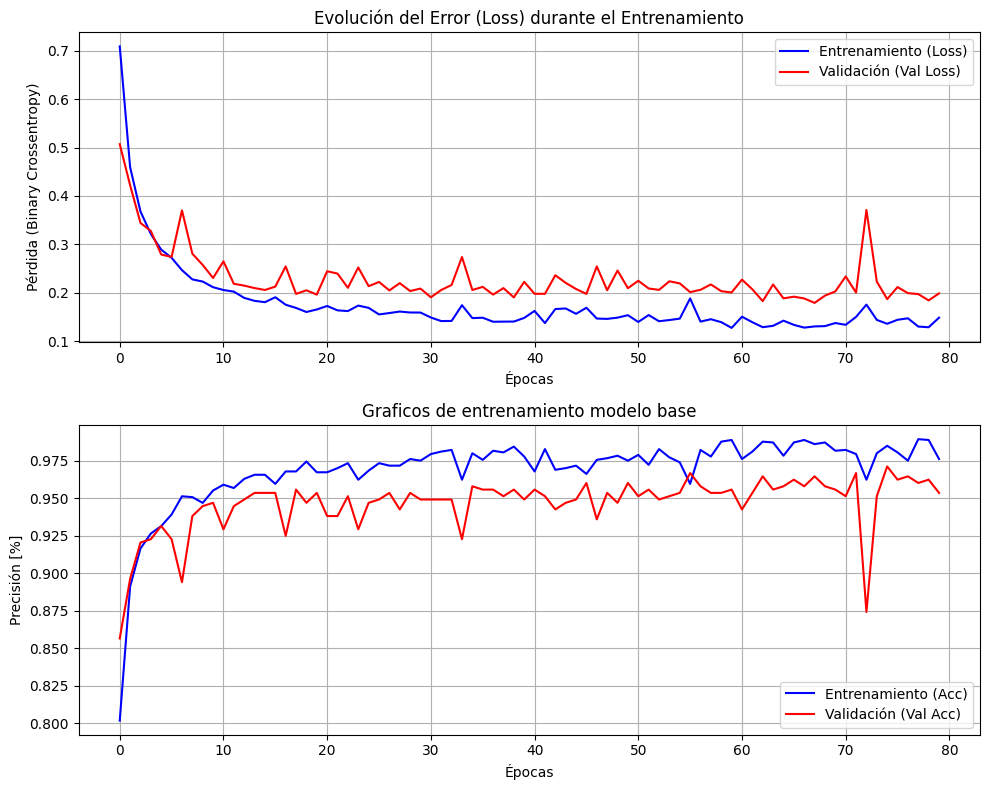

In [9]:


fig = plot_stats(history=historial_1)
plt.title("Graficos de entrenamiento modelo base")
plt.show(fig)


In [10]:
model_perfom(red_cnn_completa,data_test, y_test,threshold= 0.2 )

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

NOT FALL (0)       0.99      0.95      0.97       374
    FALL (1)       0.82      0.95      0.88        79

    accuracy                           0.95       453
   macro avg       0.90      0.95      0.92       453
weighted avg       0.96      0.95      0.95       453


=== MATRIZ DE CONFUSIÓN ===
                  Predice NO CAÍDA   Predice CAÍDA
Real NO CAÍDA:    357                 17
Real CAÍDA:       4                 75


In [11]:
## Evaluando con los datos de validacion

datos_val_normalizados = escalador.escalar_datos(data_val)
# Agrega la dimension para coincidir con el input
datos_val_normalizados = np.expand_dims(datos_val_normalizados, axis=-1)

model_perfom(red_cnn_completa, datos_val_normalizados, y_val,threshold= 0.2)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

NOT FALL (0)       0.98      0.98      0.98       205
    FALL (1)       0.90      0.91      0.91        47

    accuracy                           0.96       252
   macro avg       0.94      0.95      0.94       252
weighted avg       0.96      0.96      0.96       252


=== MATRIZ DE CONFUSIÓN ===
                  Predice NO CAÍDA   Predice CAÍDA
Real NO CAÍDA:    200                 5
Real CAÍDA:       4                 43


# Prueba de datasets cruzados

En el dataset original se tienen muestras de la muñeca, cintura y cuello, tomando en cada caso los datos de acelerometros y otros sensores. Lo que se realiza a continuacion es utilizando los datos de la cintura probar el rendimiento de la red CNN de forma de ver si estos pueden ser aprovechados dentro del dataset de entrenamiento. <br> 
Debido a la diferencia en grados de libertad entre las manos y la cintura es de esperar que no rinda tan bien como con los datos de la muñeca que fue entrenado el modelo. <br>
Otro aspecto de interes a evaluar es utilizar datos de cintura / cuello para pre-entrenar al modelo y luego hacer un fine-tunning con los datos de la muñeca.


In [12]:
## Levanto el dataset (unicamente los datos de acelerometro)
data_waist = extraer_datos_csv(path='./Datasets/outputs_FallAI_Dataset_Waist', file = 'Event_FallAIIDDataSet_*.txt', sensors= ['AccX','AccY','AccZ'])
data_waist.shape

## Extraigo los Tags del dataset

tags_waist = extraer_tags_csv(path='./Datasets/outputs_FallAI_Dataset_Waist', file = 'Event_FallAIIDDataSet_*.txt')


print(f"El shape de data es: {data_waist.shape}")
print(f"El shape de tags es: {tags_waist.shape}")


El shape de data es: (1798, 520, 3)
El shape de tags es: (1798,)


In [13]:

## usamos el mismo escaler que se uso para los datos de muñeca.
datos_normalizados_waist = escalador.escalar_datos(data_waist)

# Agrega la dimension para coincidir con el input
datos_evaluacion_waist = np.expand_dims(datos_normalizados_waist, axis=-1)

print(f"Shape datos_entrenamiento {datos_evaluacion_waist.shape}")


Shape datos_entrenamiento (1798, 520, 3, 1)


In [14]:

tags_waist = np.array(tags_waist)
resultados = red_cnn_completa.evaluate(datos_evaluacion_waist, tags_waist, verbose=1)


57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8526 - loss: 0.4918 - recall: 0.5966   


In [15]:
model_perfom(red_cnn_completa,datos_evaluacion_waist,tags_waist  )


57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

NOT FALL (0)       0.87      0.94      0.90      1332
    FALL (1)       0.78      0.60      0.68       466

    accuracy                           0.85      1798
   macro avg       0.83      0.77      0.79      1798
weighted avg       0.85      0.85      0.85      1798


=== MATRIZ DE CONFUSIÓN ===
                  Predice NO CAÍDA   Predice CAÍDA
Real NO CAÍDA:    1255                 77
Real CAÍDA:       188                 278


En este caso se puede ver que el cruzar los datasets da un valor menor de todos las metricas en especial el recall siendo para "no caidas" y "caidas" 0.9 y 0.62 respectivamente en el caso de datasets cruzados vs los 0.96 y 0.91 para el caso de dataset de muñeca. <br>
Esto es de esperar ya que estamos probando el modelo de la muñeca con datos de la cintura, en donde los sensores tienen distintos patrones de movimientos debido a la diferencia de grados de libertad. Si bien se puede observar que los datos de ambos datasets no son perfectamente compatibles, estos datos puede ser utilizados para mejorar el modelo final.<br>
Como técnica para aprovechar los datos se utilizara el transfer-learning una tecnica que permite aprovechar un modelo pre-entrenado con una serie de datos y luego realizar un fine-tuning con los datos reales que se van a utilizar.<br>
En este caso se utilizarán los datos de la cintura para entrena el modelo y luego realizar un fine-tuning con los datos de la muñeca. 

## Modelo entrenado con datos de cintura

In [16]:

model_transfer_learning = tf.keras.Sequential([
    autoencoder.encoder, # Desacoplo el decoder
    neuralnetwork.modelNN
])

model_transfer_learning.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy', 
    metrics=[
        'accuracy',
        tf.keras.metrics.Recall(name='recall')]
)

In [17]:
escalador_transfer_learning = dataScaler() ## Fitea los datos y guarda sus coef.

datos_normalizados = escalador_transfer_learning.escalar_datos(data_waist)

# Agrega la dimension para coincidir con el input
datos_entrenamiento = np.expand_dims(datos_normalizados, axis=-1)

# obtengo datos de prueba y de entrenamiento
data_train, data_test, y_train, y_test = train_test_split(datos_entrenamiento,tags_waist, test_size=0.2, random_state=21)


In [18]:

historial_2 = model_transfer_learning.fit(data_train,y_train,
                    epochs=100,
                    validation_data=(data_test, y_test))

Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9270 - loss: 0.2742 - recall: 0.8916 - val_accuracy: 0.9528 - val_loss: 0.2054 - val_recall: 0.9072
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9576 - loss: 0.2049 - recall: 0.9350 - val_accuracy: 0.9500 - val_loss: 0.1894 - val_recall: 0.8969
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9694 - loss: 0.1738 - recall: 0.9458 - val_accuracy: 0.9556 - val_loss: 0.1873 - val_recall: 0.8763
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9791 - loss: 0.1487 - recall: 0.9512 - val_accuracy: 0.9694 - val_loss: 0.1675 - val_recall: 0.9691
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9819 - loss: 0.1382 - recall: 0.9675 - val_accuracy: 0.9750 - val_loss: 0.1655 - val_recall: 0.9485
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9840 - loss: 0.1324 - recall: 0.9648 - val_accuracy: 0.9750 - val_loss: 0.1509 - val_recall: 0.9794
Epoch 7/10

In [19]:
model_transfer_learning.summary()
model_transfer_learning.layers[0].summary()

model_transfer_learning.layers[1].summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 62, 1, 128)     │        32,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 1)              │        79,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 270,899 (1.03 MB)

 Trainable params: 79,419 (310.23 KB)

 Non-trainable params: 32,640 (127.50 KB)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 7936)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        79,370 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            44 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,419 (310.23 KB)

 Trainable params: 79,419 (310.23 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Salvamos los valores obtenidos del pre-entrenamiento.

model_transfer_learning.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), ## Para fine-tuning se utiliza un learning rate menor para evitar destruir lo aprendido.
    loss='binary_crossentropy', 
    metrics=[
        'accuracy',
        tf.keras.metrics.Recall(name='recall')]
)

### Fine-Tuning

# Partiendo del entrenamiento con los datos de la cadera, ahora procedemos a optimizar la red con los datos de la muñeca. Los pesos se incializan con los valores obtenidos en la cintura completando asi el transfer learning.

escalador_wrist = dataScaler() ## Fitea los datos y guarda sus coef.
datos_normalizados = escalador_wrist.escalar_datos(data)
datos_entrenamiento = np.expand_dims(datos_normalizados, axis=-1)
# obtengo datos de prueba y de entrenamiento
data_train, data_test, y_train, y_test = train_test_split(datos_entrenamiento,tags, test_size=0.2, random_state=21)

historial = model_transfer_learning.fit(data_train, y_train,epochs=80,validation_data=(data_test, y_test))

Epoch 1/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7961 - loss: 0.9815 - recall: 0.2594 - val_accuracy: 0.8389 - val_loss: 0.6904 - val_recall: 0.3797
Epoch 2/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7961 - loss: 0.8341 - recall: 0.3552 - val_accuracy: 0.8366 - val_loss: 0.6184 - val_recall: 0.4430
Epoch 3/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7950 - loss: 0.7438 - recall: 0.4207 - val_accuracy: 0.8455 - val_loss: 0.5707 - val_recall: 0.5443
Epoch 4/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8055 - loss: 0.6781 - recall: 0.4660 - val_accuracy: 0.8499 - val_loss: 0.5255 - val_recall: 0.5949
Epoch 5/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8099 - loss: 0.6245 - recall: 0.5013 - val_accuracy: 0.8499 - val_loss: 0.4894 - val_recall: 0.5949
Epoch 6/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8166 - loss: 0.5793 - recall: 0.5466 - val_accuracy: 0.8477 - val_loss: 0.4602 - val_recall: 0.6329
Epoch 7/80
57/57

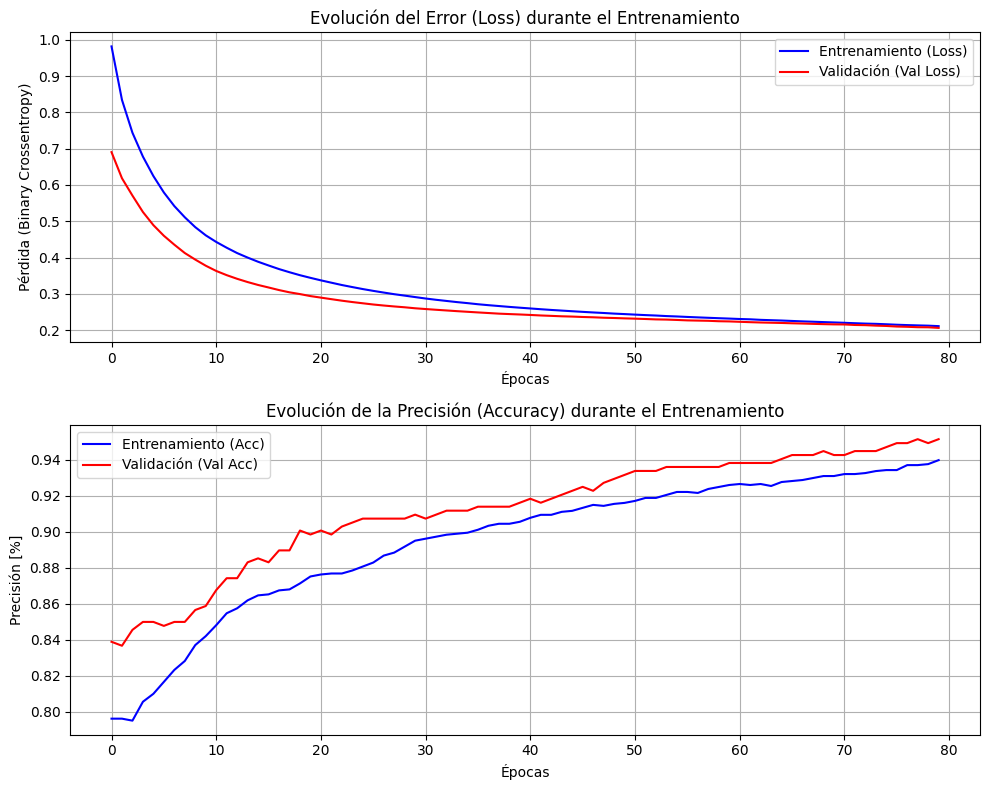

In [21]:
fig = plot_stats(history=historial)
plt.show(fig)

In [22]:

model_perfom(model_transfer_learning, data_test, y_test,threshold= 0.2)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

NOT FALL (0)       0.99      0.90      0.94       374
    FALL (1)       0.66      0.95      0.78        79

    accuracy                           0.91       453
   macro avg       0.83      0.92      0.86       453
weighted avg       0.93      0.91      0.91       453


=== MATRIZ DE CONFUSIÓN ===
                  Predice NO CAÍDA   Predice CAÍDA
Real NO CAÍDA:    336                 38
Real CAÍDA:       4                 75


In [23]:
## Evaluando con los datos de validacion

datos_val_normalizados = escalador_transfer_learning.escalar_datos(data_val)
# Agrega la dimension para coincidir con el input
datos_val_normalizados = np.expand_dims(datos_val_normalizados, axis=-1)


model_perfom(model_transfer_learning, datos_val_normalizados, y_val,threshold= 0.2)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

NOT FALL (0)       0.97      0.93      0.95       205
    FALL (1)       0.74      0.89      0.81        47

    accuracy                           0.92       252
   macro avg       0.86      0.91      0.88       252
weighted avg       0.93      0.92      0.92       252


=== MATRIZ DE CONFUSIÓN ===
                  Predice NO CAÍDA   Predice CAÍDA
Real NO CAÍDA:    190                 15
Real CAÍDA:       5                 42


### Resultado de transfer-learning

El resultado obtenido no muestra indicios de que pueda mejorar considerablemente el resultado de la red. 

Resultados previo transfer-learning <br>
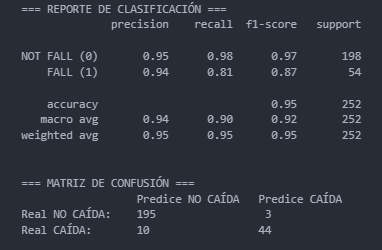

Resultados post transfer-learning<br>
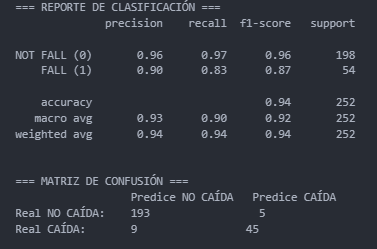

In [24]:
model_transfer_learning.save("./Modelos/modelo_acelerometro.keras")

## Sensibilidad al cambio de eje

Una de las características a tener en cuenta es que tan sensible es el modelo al cambio de ejes, por ejemplo si se coloca la orientación del sensor en forma alterada a la que se utilizó para obtener el dataset. Para obtener esto lo que se propone es utilizando el modelo previamente entrenado, correr un set de pruebas con las orientaciones modificadas.

![Cambio_orientacion.png](imgs/Cambio_orientacion.png)


In [25]:
def rotacion(datos, matriz_rot):
    data = datos.copy()
    for indx, t in enumerate(data):
        data[indx] = t.dot(matriz_rot)

    return data



matriz_rot = np.array([
    [-1,  0,  0],
    [ 0, -1,  0],
    [ 0,  0,  1]
])


data_rot = rotacion(data_val, matriz_rot)

datos_val_normalizados = escalador.escalar_datos(data_rot)
# Agrega la dimension para coincidir con el input
datos_val_normalizados = np.expand_dims(datos_val_normalizados, axis=-1)


model_perfom(red_cnn_completa, datos_val_normalizados, y_val,threshold= 0.2)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

NOT FALL (0)       0.92      0.79      0.85       205
    FALL (1)       0.43      0.68      0.52        47

    accuracy                           0.77       252
   macro avg       0.67      0.74      0.69       252
weighted avg       0.82      0.77      0.79       252


=== MATRIZ DE CONFUSIÓN ===
                  Predice NO CAÍDA   Predice CAÍDA
Real NO CAÍDA:    162                 43
Real CAÍDA:       15                 32


Comparando el valor previo al cambio de orientacion y posterior se observa que el modelo es altamente dependiente de esta modificacion, siendo que es necesario poder ajustar los datos para que coincidad con los datos de entrenamiento

Valores sin cambio de orientacion: <br>

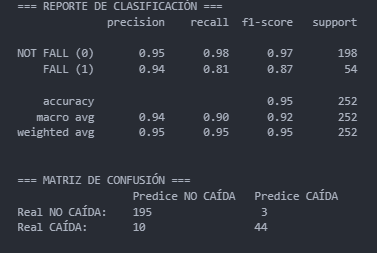

Valores con cambio de orientacion: <br>
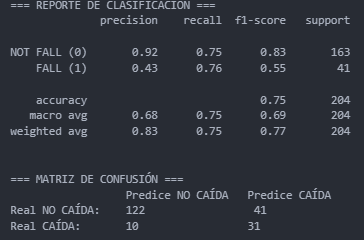

Los cambios de orientacion corresponde a los visualizados en la imagen superior 